## Motivation

In [ ]:
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import torch
from IPython.display import Image, display

from utils.pooling import covariance_pooling, mean_pooling

In [ ]:
def _hex_to_rgba(hex_color: str, alpha: float = 1.0) -> str:
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"


def _covariance_ellipse(mu, sigma, k=1.0, num=240):
    vals, vecs = np.linalg.eigh(sigma)
    M = vecs @ np.diag(np.sqrt(np.clip(vals, 0.0, None)))
    t = np.linspace(0, 2 * np.pi, num=num, endpoint=True)
    circle = np.stack([np.cos(t), np.sin(t)], axis=0)
    ellipse = mu.reshape(2, 1) + k * (M @ circle)
    return ellipse[0], ellipse[1]


def _mean_cov(X: np.ndarray):
    X_t = torch.from_numpy(X).float()
    mask = torch.ones(X_t.shape[0])
    mu = mean_pooling(X_t, mask).numpy()
    sigma = covariance_pooling(X_t, mask).numpy()
    return mu, sigma


def plot_two_distributions(
    mu1,
    sigma1,
    mu2,
    sigma2,
    n1=30,
    n2=30,
    seed=None,
    color1="#2C77BA",
    color2="#BF8800",
    ellipse_prob=0.8,
    fig_width=100,
    fig_height=80,
    x_range=None,
    y_range=None,
    save_path="figs/other_visualizations/motivation.png",
):
    # sample from each Gaussian, normalize by empirical mean norm
    mu1 = np.asarray(mu1, dtype=float).reshape(2)
    mu2 = np.asarray(mu2, dtype=float).reshape(2)
    sigma1 = np.asarray(sigma1, dtype=float).reshape(2, 2)
    sigma2 = np.asarray(sigma2, dtype=float).reshape(2, 2)

    rng = np.random.default_rng(seed)
    samples1 = rng.multivariate_normal(mu1, sigma1, size=n1)
    samples2 = rng.multivariate_normal(mu2, sigma2, size=n2)

    mu1_hat, _ = _mean_cov(samples1)
    mu2_hat, _ = _mean_cov(samples2)

    norm1 = np.linalg.norm(mu1_hat)
    norm2 = np.linalg.norm(mu2_hat)

    samples1 /= norm1
    samples2 /= norm2

    mu1_hat, sigma1_hat = _mean_cov(samples1)
    mu2_hat, sigma2_hat = _mean_cov(samples2)

    k_eff = np.sqrt(-2.0 * np.log(1.0 - ellipse_prob))
    e1x, e1y = _covariance_ellipse(mu1_hat, sigma1_hat, k=k_eff)
    e2x, e2y = _covariance_ellipse(mu2_hat, sigma2_hat, k=k_eff)

    # traces
    fig = go.Figure()

    # ellipses
    for ex, ey, color in [(e2x, e2y, color2), (e1x, e1y, color1)]:
        fig.add_trace(
            go.Scatter(
                x=ex,
                y=ey,
                mode="lines",
                line=dict(width=0),
                fill="toself",
                opacity=0.20,
                hoverinfo="skip",
                showlegend=False,
                fillcolor=color,
            )
        )

    for ex, ey, color in [(e2x, e2y, color2), (e1x, e1y, color1)]:
        fig.add_trace(
            go.Scatter(
                x=ex,
                y=ey,
                mode="lines",
                line=dict(width=2.4, color=color),
                hoverinfo="skip",
                showlegend=False,
            )
        )

    # samples
    for samples, color in [(samples1, color1), (samples2, color2)]:
        fig.add_trace(
            go.Scatter(
                x=samples[:, 0],
                y=samples[:, 1],
                mode="markers",
                marker=dict(
                    symbol="circle",
                    size=8,
                    color=_hex_to_rgba(color, alpha=0.9),
                    line=dict(width=1.2, color="#DDDDDD"),
                ),
                hoverinfo="skip",
                showlegend=False,
            )
        )

    # mean markers
    for mu_hat, color in [(mu2_hat, color2), (mu1_hat, color1)]:
        fig.add_trace(
            go.Scatter(
                x=[mu_hat[0]],
                y=[mu_hat[1]],
                mode="markers",
                marker=dict(
                    symbol="star",
                    size=24,
                    color=color,
                    line=dict(width=1.2, color="#DDDDDD"),
                ),
                hoverinfo="skip",
                showlegend=False,
            )
        )

    # layout and axes
    axis_style = dict(
        showgrid=False,
        zeroline=False,
        showline=False,
        showticklabels=False,
    )
    fig.update_layout(
        showlegend=False,
        width=fig_width,
        height=fig_height,
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        font=dict(size=32, family="Times New Roman, Arial"),
        margin=dict(l=5, r=5, t=5, b=15, pad=0),
    )
    fig.update_xaxes(range=x_range, autorange=(x_range is None), **axis_style)
    fig.update_yaxes(range=y_range, autorange=(y_range is None), **axis_style)

    # save and display
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_image(str(save_path), format="png", width=fig_width, height=fig_height)
    display(Image(str(save_path)))
    # fig.write_image(str(save_path.with_suffix(".pdf")), format="pdf", width=fig_width, height=fig_height)
    # fig.show()

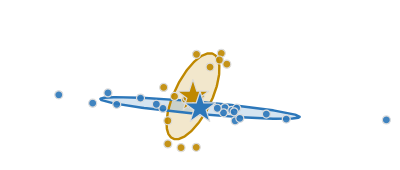

In [ ]:
mu1 = [0.9, 0.0]
sigma1 = [[1.9, -0.25], [-0.25, 0.15]]
mu2 = [1.0, 0.0]
sigma2 = [[0.05, 0.15], [0.15, 1.5]]

plot_two_distributions(
    mu1,
    sigma1,
    mu2,
    sigma2,
    ellipse_prob=0.6,
    n1=20,
    n2=15,
    seed=0,
    fig_width=400,
    fig_height=170,
    x_range=[-1.3, 3.3],
    y_range=[-1.6, 3.5],
    save_path="figs/other_visualizations/motivation.png",
)

## Distribution pairs

In [ ]:
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import torch
from IPython.display import Image, display

from utils.distance import (
    calc_batched_bures_wasserstein_squared_distance,
    calc_batched_euclidean_squared_distance,
)
from utils.pooling import covariance_pooling, mean_pooling
from utils.socm import calc_socm

In [ ]:
def plot_two_distributions(
    X1,
    X2,
    color1="#2C77BA",
    color2="#BF8800",
    fig_width=100,
    fig_height=80,
    x_range=None,
    y_range=None,
    save_path="figs/other_visualizations/two_distribution.png",
):
    # compute empirical mean and covariance, then draw ellipses
    X1 = np.asarray(X1, dtype=float).reshape(-1, 2)
    X2 = np.asarray(X2, dtype=float).reshape(-1, 2)

    mu1, sigma1 = _mean_cov(X1)
    mu2, sigma2 = _mean_cov(X2)

    k_eff = np.sqrt(-2.0 * np.log(1.0 - 0.45))
    e1x, e1y = _covariance_ellipse(mu1, sigma1, k=k_eff)
    e2x, e2y = _covariance_ellipse(mu2, sigma2, k=k_eff)

    # traces
    fig = go.Figure()

    # ellipses
    for ex, ey, color in [(e2x, e2y, color2), (e1x, e1y, color1)]:
        fig.add_trace(
            go.Scatter(
                x=ex,
                y=ey,
                mode="lines",
                line=dict(width=0),
                fill="toself",
                opacity=0.20,
                hoverinfo="skip",
                showlegend=False,
                fillcolor=color,
            )
        )

    for ex, ey, color in [(e2x, e2y, color2), (e1x, e1y, color1)]:
        fig.add_trace(
            go.Scatter(
                x=ex,
                y=ey,
                mode="lines",
                line=dict(width=1.5, color=color),
                hoverinfo="skip",
                showlegend=False,
            )
        )

    # samples
    for X, color in [(X1, color1), (X2, color2)]:
        fig.add_trace(
            go.Scatter(
                x=X[:, 0],
                y=X[:, 1],
                mode="markers",
                marker=dict(
                    symbol="circle",
                    size=5,
                    color=_hex_to_rgba(color, alpha=0.9),
                    line=dict(width=1.2, color="#DDDDDD"),
                ),
                hoverinfo="skip",
                showlegend=False,
            )
        )

    # mean markers
    for mu, color in [(mu2, color2), (mu1, color1)]:
        fig.add_trace(
            go.Scatter(
                x=[mu[0]],
                y=[mu[1]],
                mode="markers",
                marker=dict(
                    symbol="star",
                    size=14,
                    color=color,
                    line=dict(width=1.2, color="#DDDDDD"),
                ),
                hoverinfo="skip",
                showlegend=False,
            )
        )

    # layout and axes
    axis_style = dict(
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=1,
        mirror=True,
        showticklabels=False,
        title_text=None,
    )
    fig.update_layout(
        showlegend=False,
        width=fig_width,
        height=fig_height,
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        font=dict(size=32, family="Times New Roman, Arial"),
        margin=dict(l=5, r=5, t=5, b=15, pad=0),
    )
    fig.update_xaxes(range=x_range, autorange=(x_range is None), **axis_style)
    fig.update_yaxes(range=y_range, autorange=(y_range is None), **axis_style)

    # save and display
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_image(str(save_path), format="png", width=fig_width, height=fig_height)
    display(Image(str(save_path)))
    # fig.write_image(str(save_path.with_suffix(".pdf")), format="pdf", width=fig_width, height=fig_height)
    # fig.show()
    return mu1, sigma1, mu2, sigma2

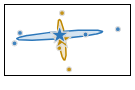

d_mu: 0.017346840351819992, d_sigma: 0.6099903583526611, SOCM: 0.599408952990168


In [ ]:
# The distribution-pair visualizations may differ slightly from those in the paper.

mu1, sigma1, mu2, sigma2 = plot_two_distributions(
    X1=[
        [0.86873452, -0.18509823],
        [1.78166877, -0.10265358],
        [-0.60442116, -0.01335956],
        [2.95868732, 0.19030783],
        [-0.80252751, -0.57933426],
    ],
    X2=[
        [0.8901537, -0.11966183],
        [1.1829576, -1.99667556],
        [0.82457389, -0.83968229],
        [0.78244024, -0.05063433],
        [0.92669637, 1.06315387],
    ],
    x_range=[-1.15, 3.4],
    y_range=[-2.3, 1.5],
    fig_width=135,
    fig_height=90,
    save_path="figs/other_visualizations/distribution_pairs_1.png",
)
d_mu = (
    calc_batched_euclidean_squared_distance(torch.tensor(mu1), torch.tensor(mu2)).item()
    / 4
)
d_sigma = (
    calc_batched_bures_wasserstein_squared_distance(
        torch.tensor(sigma1), torch.tensor(sigma2)
    ).item()
    / 4
)
socm = calc_socm(d_mu, d_sigma)
print(f"d_mu: {d_mu}, d_sigma: {d_sigma}, SOCM: {socm}")

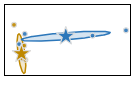

d_mu: 0.8466139435768127, d_sigma: 0.6099903583526611, SOCM: 0.0935640155238815


In [ ]:
mu1, sigma1, mu2, sigma2 = plot_two_distributions(
    X1=[
        [0.86873452, -0.18509823],
        [1.78166877, -0.10265358],
        [-0.60442116, -0.01335956],
        [2.95868732, 0.19030783],
        [-0.80252751, -0.57933426],
    ],
    X2=[
        [-0.6901537, -1.38033817],
        [-0.9829576, 0.49667556],
        [-0.62457389, -0.66031771],
        [-0.58244024, -1.44936567],
        [-0.72669637, -2.56315387],
    ],
    x_range=[-1.3, 3.1],
    y_range=[-2.3, 1.6],
    fig_width=135,
    fig_height=90,
    save_path="figs/other_visualizations/distribution_pairs_2.png",
)
d_mu = (
    calc_batched_euclidean_squared_distance(torch.tensor(mu1), torch.tensor(mu2)).item()
    / 4
)
d_sigma = (
    calc_batched_bures_wasserstein_squared_distance(
        torch.tensor(sigma1), torch.tensor(sigma2)
    ).item()
    / 4
)
socm = calc_socm(d_mu, d_sigma)
print(f"d_mu: {d_mu}, d_sigma: {d_sigma}, SOCM: {socm}")

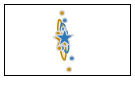

d_mu: 0.004999990575015545, d_sigma: 0.0184650719165802, SOCM: 0.018372746731030315


In [ ]:
mu1, sigma1, mu2, sigma2 = plot_two_distributions(
    X1=[
        [0.9901537, 0.18033817],
        [1.282957, -1.39667556],
        [0.92457389, -0.83968229],
        [0.88244024, -0.05063433],
        [1.02669637, 0.66315387],
    ],
    X2=[
        [0.8901537, -0.11966183],
        [1.1829576, -1.99667556],
        [0.82457389, -0.83968229],
        [0.78244024, -0.05063433],
        [0.92669637, 1.06315387],
    ],
    x_range=[-1.15, 3.4],
    y_range=[-2.3, 1.5],
    fig_width=135,
    fig_height=90,
    save_path="figs/other_visualizations/distribution_pairs_3.png",
)
d_mu = (
    calc_batched_euclidean_squared_distance(torch.tensor(mu1), torch.tensor(mu2)).item()
    / 4
)
d_sigma = (
    calc_batched_bures_wasserstein_squared_distance(
        torch.tensor(sigma1), torch.tensor(sigma2)
    ).item()
    / 4
)
socm = calc_socm(d_mu, d_sigma)
print(f"d_mu: {d_mu}, d_sigma: {d_sigma}, SOCM: {socm}")

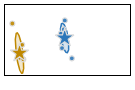

d_mu: 0.8438069820404053, d_sigma: 0.0184650719165802, SOCM: 0.0028841153094916194


In [ ]:
mu1, sigma1, mu2, sigma2 = plot_two_distributions(
    X1=[
        [0.9901537, 0.18033817],
        [1.282957, -1.39667556],
        [0.92457389, -0.83968229],
        [0.88244024, -0.05063433],
        [1.02669637, 0.66315387],
    ],
    X2=[
        [-0.5901537, -1.38033817],
        [-0.8829576, 0.49667556],
        [-0.52457389, -0.66031771],
        [-0.48244024, -1.44936567],
        [-0.62669637, -2.56315387],
    ],
    x_range=[-1.15, 3.4],
    y_range=[-2.3, 1.5],
    fig_width=135,
    fig_height=90,
    save_path="figs/other_visualizations/distribution_pairs_4.png",
)
d_mu = (
    calc_batched_euclidean_squared_distance(torch.tensor(mu1), torch.tensor(mu2)).item()
    / 4
)
d_sigma = (
    calc_batched_bures_wasserstein_squared_distance(
        torch.tensor(sigma1), torch.tensor(sigma2)
    ).item()
    / 4
)
socm = calc_socm(d_mu, d_sigma)
print(f"d_mu: {d_mu}, d_sigma: {d_sigma}, SOCM: {socm}")

## heatmap

In [ ]:
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
from IPython.display import Image, display

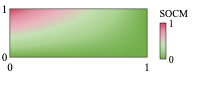

In [ ]:
colorscale = [
    [0.0, "#70AD47"],
    [0.2, "#A9D18E"],
    [0.4, "#C5E0B4"],
    [0.6, "#EBB5BF"],
    [0.8, "#E18FA0"],
    [1.0, "#CD4560"],
]

res = 500
d_mu = np.linspace(0.0, 1.0, res)
d_sigma = np.linspace(0.0, 1.0, res)
D_mu, D_sigma = np.meshgrid(d_mu, d_sigma)
socm = (1.0 - D_mu) * D_sigma

# traces
fig = go.Figure(
    data=go.Heatmap(
        x=d_mu,
        y=d_sigma,
        z=socm,
        colorscale=colorscale,
        zmin=0.0,
        zmax=1.0,
        zsmooth="best",
        showscale=True,
        colorbar=dict(
            title=dict(
                text="SOCM",
                side="top",
                font=dict(size=10, color="black", family="Times New Roman"),
            ),
            tickmode="array",
            tickvals=[0.0, 1.0],
            ticktext=["0", "1"],
            tickfont=dict(size=10, color="black", family="Times New Roman"),
            thickness=6,
            len=1.5,
            outlinewidth=0.5,
            outlinecolor="black",
        ),
    )
)

# layout and axes
axis_style = dict(
    tickmode="array",
    tickvals=[0, 1],
    ticktext=["0", "1"],
    tickfont=dict(size=11),
    title_standoff=0,
    showgrid=False,
    zeroline=False,
    showline=True,
    linecolor="black",
    linewidth=0.5,
    mirror=True,
)
fig.update_layout(
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    width=200,
    height=90,
    margin=dict(l=2, r=2, t=2, b=40),
    font=dict(size=11, color="black", family="Times New Roman"),
)
fig.update_xaxes(range=[0, 1], **axis_style)
fig.update_yaxes(range=[0, 1], **axis_style)

# save and display
save_path = Path("figs/other_visualizations/heatmap.png")
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.write_image(str(save_path), format="png", width=200, height=90)
display(Image(str(save_path)))
# fig.write_image(str(save_path.with_suffix(".pdf")), format="pdf", width=200, height=90)
# fig.show()